

1. Environment & imports
2. Connect to PostgreSQL
3. Load workforce_analytics
4. Validate ML dataset
5. Define features (X) and target (y)
6. Identify numerical/categorical features
7. Train/test split
8. Preprocessing pipeline
9. Logistic Regression
10. Random Forest
11. Model evaluation
12. Model comparison
13. Feature importance
14. Save the best model

In [8]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
from getpass import getpass

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
DB_USER = "postgres"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "workforce_intelligence"

DB_PASSWORD = getpass("Enter PostgreSQL password: ")

Enter PostgreSQL password:  ········


In [10]:
connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME
)

engine = create_engine(connection_url)

print("Database engine created successfully.")

Database engine created successfully.


In [4]:
with engine.connect() as connection:
    result = connection.execute(text("SELECT 1"))
    print("Database connection successful:", result.fetchone())

Database connection successful: (1,)


In [11]:
query = """
SELECT *
FROM workforce_analytics;
"""

with engine.connect() as connection:
    workforce_df = pd.read_sql(
        text(query),
        connection
    )

print("ML dataset loaded successfully.")
print("Shape:", workforce_df.shape)

ML dataset loaded successfully.
Shape: (1470, 33)


In [12]:
workforce_df.head()

,employee_id,age,gender,marital_status,education,education_field,department,job_level,job_role,business_travel,...,stock_option_level,environment_satisfaction,job_involvement,job_satisfaction,relationship_satisfaction,work_life_balance,performance_rating,training_times_last_year,attrition,attrition_flag
0,1,41,Female,Single,2,Life Sciences,Sales,2,Sales Executive,Travel_Rarely,...,0,2,3,4,1,1,3,0,Yes,1
1,2,49,Male,Married,1,Life Sciences,Research & Development,2,Research Scientist,Travel_Frequently,...,1,3,2,2,4,3,4,3,No,0
2,4,37,Male,Single,2,Other,Research & Development,1,Laboratory Technician,Travel_Rarely,...,0,4,2,3,2,3,3,3,Yes,1
3,5,33,Female,Married,4,Life Sciences,Research & Development,1,Research Scientist,Travel_Frequently,...,0,4,3,3,3,3,3,3,No,0
4,7,27,Male,Married,1,Medical,Research & Development,1,Laboratory Technician,Travel_Rarely,...,1,1,3,2,4,3,3,3,No,0


In [13]:
print(workforce_df.dtypes)

employee_id                    int64
age                            int64
gender                        object
marital_status                object
education                      int64
education_field               object
department                    object
job_level                      int64
job_role                      object
business_travel               object
total_working_years            int64
years_at_company               int64
years_in_current_role          int64
years_since_last_promotion     int64
years_with_curr_manager        int64
num_companies_worked           int64
distance_from_home             int64
overtime                      object
daily_rate                     int64
hourly_rate                    int64
monthly_income                 int64
monthly_rate                   int64
percent_salary_hike            int64
stock_option_level             int64
environment_satisfaction       int64
job_involvement                int64
job_satisfaction               int64
r

In [14]:
print("Missing values:")
print(workforce_df.isnull().sum()[workforce_df.isnull().sum() > 0])

Missing values:
Series([], dtype: int64)


In [15]:
print("Target distribution:")
print(workforce_df["attrition_flag"].value_counts())

print("\nTarget percentage:")
print(
    workforce_df["attrition_flag"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution:
attrition_flag
0    1233
1     237
Name: count, dtype: int64

Target percentage:
attrition_flag
0    83.88
1    16.12
Name: proportion, dtype: float64


In [16]:
# Separate features and target

X = workforce_df.drop(columns=["attrition_flag", "attrition"])
y = workforce_df["attrition_flag"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (1470, 31)
Target shape: (1470,)

Target distribution:
attrition_flag
0    1233
1     237
Name: count, dtype: int64


In [17]:
print("Numerical features:")
print(X.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical features:")
print(X.select_dtypes(include=["object", "category"]).columns.tolist())

Numerical features:
['employee_id', 'age', 'education', 'job_level', 'total_working_years', 'years_at_company', 'years_in_current_role', 'years_since_last_promotion', 'years_with_curr_manager', 'num_companies_worked', 'distance_from_home', 'daily_rate', 'hourly_rate', 'monthly_income', 'monthly_rate', 'percent_salary_hike', 'stock_option_level', 'environment_satisfaction', 'job_involvement', 'job_satisfaction', 'relationship_satisfaction', 'work_life_balance', 'performance_rating', 'training_times_last_year']

Categorical features:
['gender', 'marital_status', 'education_field', 'department', 'job_role', 'business_travel', 'overtime']


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 1176
Testing samples: 294

Training target distribution:
attrition_flag
0    986
1    190
Name: count, dtype: int64

Testing target distribution:
attrition_flag
0    247
1     47
Name: count, dtype: int64


In [19]:
stratify=y

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 24
Number of categorical features: 7


In [21]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [22]:
import sys

!{sys.executable} -m pip install xgboost

You should consider upgrading via the 'c:\users\india\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

print("ML models imported successfully.")

ML models imported successfully.


In [24]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    )
}

print("Models created:")
for name in models:
    print("-", name)

Models created:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost


In [25]:
from sklearn.pipeline import Pipeline

print("Pipeline imported successfully.")

Pipeline imported successfully.


In [27]:
for name, pipeline in model_pipelines.items():
    print(f"Training {name}...")
    
    pipeline.fit(X_train, y_train)
    
    print(f"{name} trained successfully.\n")

In [28]:
model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Model pipelines created successfully.")

Model pipelines created successfully.


In [29]:
for name, pipeline in model_pipelines.items():
    print(f"Training {name}...")
    
    pipeline.fit(X_train, y_train)
    
    print(f"{name} trained successfully.\n")

Training Logistic Regression...
Logistic Regression trained successfully.

Training Decision Tree...
Decision Tree trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training Gradient Boosting...
Gradient Boosting trained successfully.

Training XGBoost...
XGBoost trained successfully.



In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

for name, pipeline in model_pipelines.items():
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

print("===== MODEL PERFORMANCE =====")
display(results_df.round(4))

===== MODEL PERFORMANCE =====


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,XGBoost,0.8605,0.6875,0.2340,0.3492,0.8400
3,Gradient Boosting,0.8673,0.7857,0.2340,0.3607,0.8310
2,Random Forest,0.8503,0.6364,0.1489,0.2414,0.8161
0,Logistic Regression,0.7517,0.3523,0.6596,0.4593,0.8145
1,Decision Tree,0.8027,0.4035,0.4894,0.4423,0.6195



===== Logistic Regression =====
[[190  57]
 [ 16  31]]


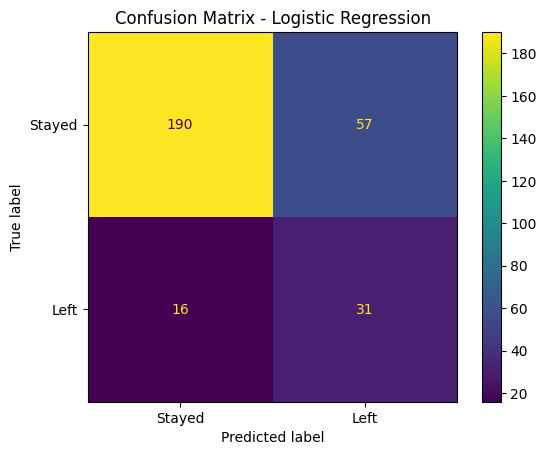


===== Decision Tree =====
[[213  34]
 [ 24  23]]


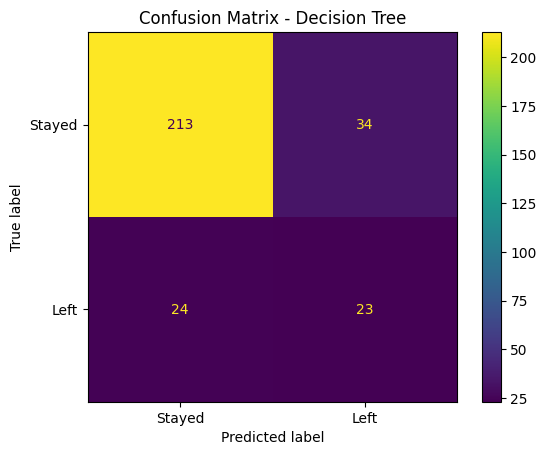


===== Random Forest =====
[[243   4]
 [ 40   7]]


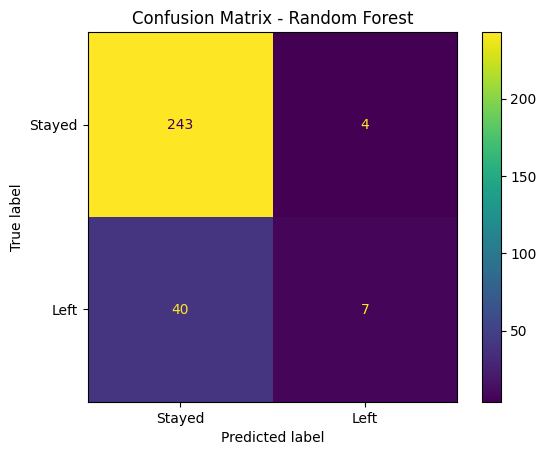


===== Gradient Boosting =====
[[244   3]
 [ 36  11]]


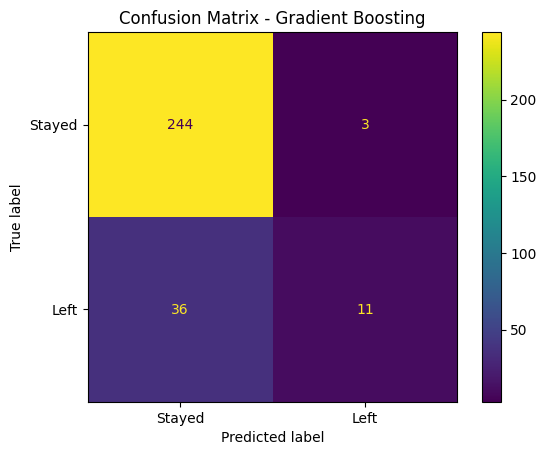


===== XGBoost =====
[[242   5]
 [ 36  11]]


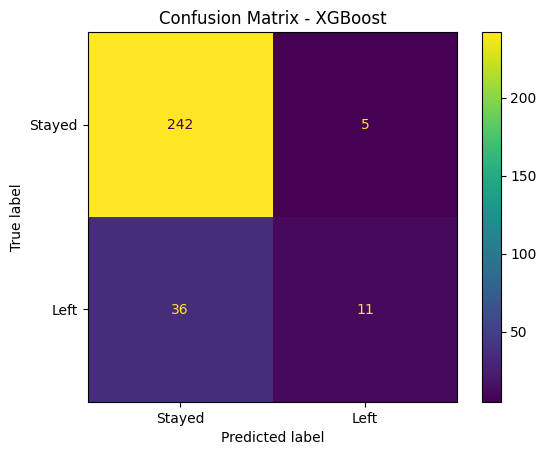

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, pipeline in model_pipelines.items():
    
    y_pred = pipeline.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n===== {name} =====")
    print(cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Stayed", "Left"]
    )
    
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [32]:
from sklearn.metrics import classification_report

for name, pipeline in model_pipelines.items():
    
    y_pred = pipeline.predict(X_test)
    
    print(f"\n{'=' * 50}")
    print(f"{name}")
    print(f"{'=' * 50}")
    
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Stayed", "Left"],
            digits=4
        )
    )


Logistic Regression
              precision    recall  f1-score   support

      Stayed     0.9223    0.7692    0.8389       247
        Left     0.3523    0.6596    0.4593        47

    accuracy                         0.7517       294
   macro avg     0.6373    0.7144    0.6491       294
weighted avg     0.8312    0.7517    0.7782       294


Decision Tree
              precision    recall  f1-score   support

      Stayed     0.8987    0.8623    0.8802       247
        Left     0.4035    0.4894    0.4423        47

    accuracy                         0.8027       294
   macro avg     0.6511    0.6759    0.6612       294
weighted avg     0.8196    0.8027    0.8102       294


Random Forest
              precision    recall  f1-score   support

      Stayed     0.8587    0.9838    0.9170       247
        Left     0.6364    0.1489    0.2414        47

    accuracy                         0.8503       294
   macro avg     0.7475    0.5664    0.5792       294
weighted avg     0.8231

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

balanced_models = {

    "Balanced Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Balanced Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ),

    "Balanced Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Balanced XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    )
}

print("Balanced models created:")
for name in balanced_models:
    print("-", name)

Balanced models created:
- Balanced Logistic Regression
- Balanced Decision Tree
- Balanced Random Forest
- Balanced XGBoost


In [34]:
balanced_pipelines = {}

for name, model in balanced_models.items():

    balanced_pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Balanced model pipelines created successfully.")

Balanced model pipelines created successfully.


In [35]:
for name, pipeline in balanced_pipelines.items():

    print(f"Training {name}...")

    pipeline.fit(X_train, y_train)

    print(f"{name} trained successfully.\n")

Training Balanced Logistic Regression...
Balanced Logistic Regression trained successfully.

Training Balanced Decision Tree...
Balanced Decision Tree trained successfully.

Training Balanced Random Forest...
Balanced Random Forest trained successfully.

Training Balanced XGBoost...
Balanced XGBoost trained successfully.



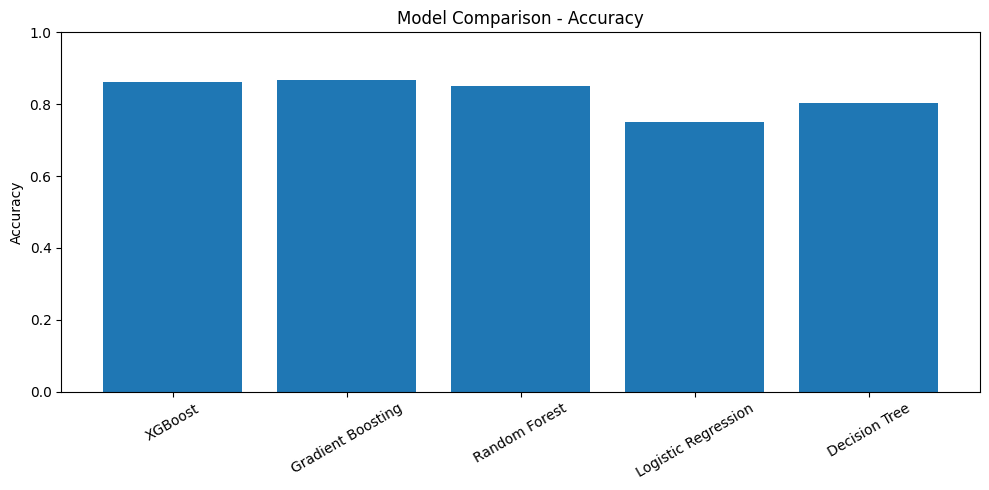

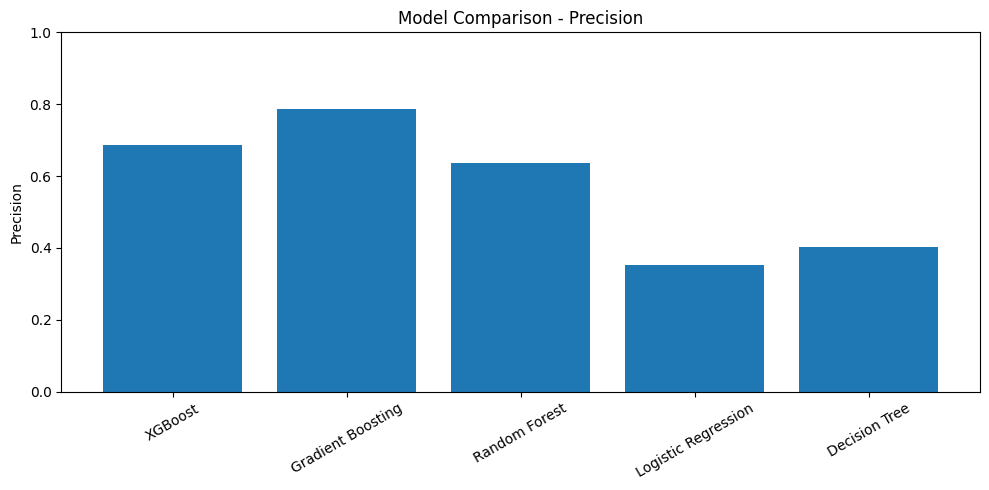

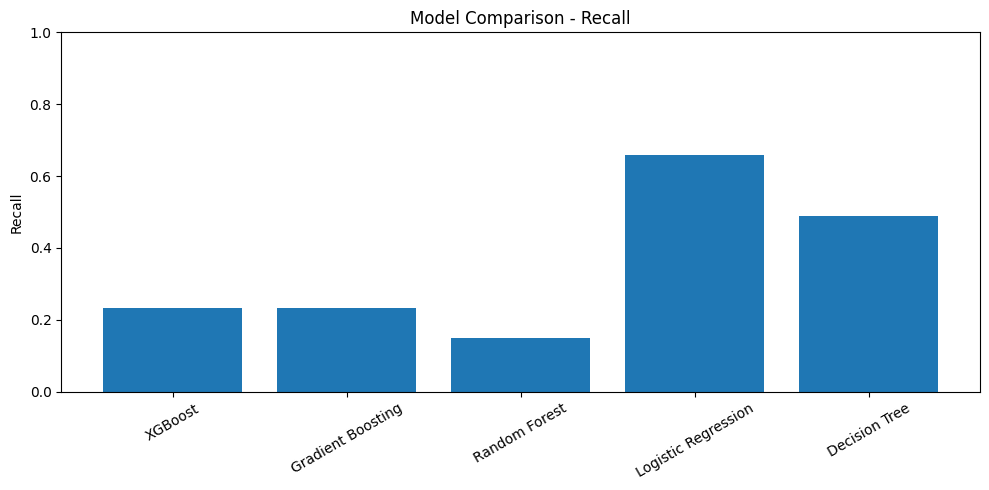

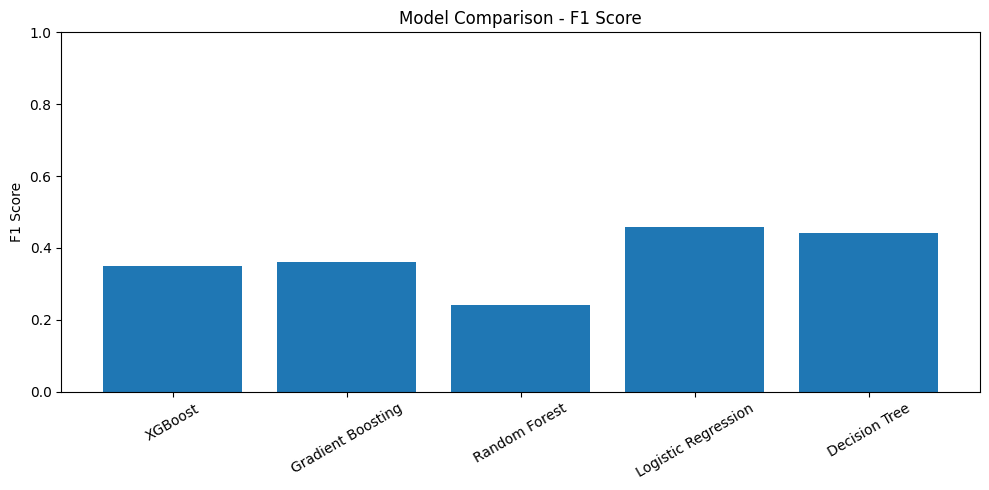

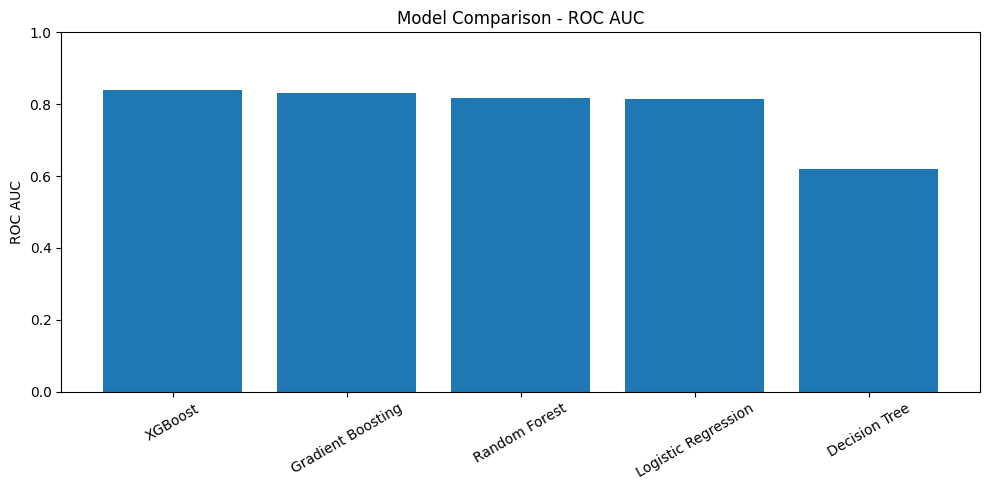

In [36]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

for metric in metrics:
    
    plt.figure(figsize=(10, 5))
    
    plt.bar(
        results_df["Model"],
        results_df[metric]
    )
    
    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=30)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

In [37]:
print("===== BEST MODEL BY METRIC =====")

for metric in metrics:
    
    best_model = results_df.loc[
        results_df[metric].idxmax(),
        "Model"
    ]
    
    best_score = results_df[metric].max()
    
    print(
        f"{metric}: {best_model} ({best_score:.4f})"
    )

===== BEST MODEL BY METRIC =====
Accuracy: Gradient Boosting (0.8673)
Precision: Gradient Boosting (0.7857)
Recall: Logistic Regression (0.6596)
F1 Score: Logistic Regression (0.4593)
ROC AUC: XGBoost (0.8400)


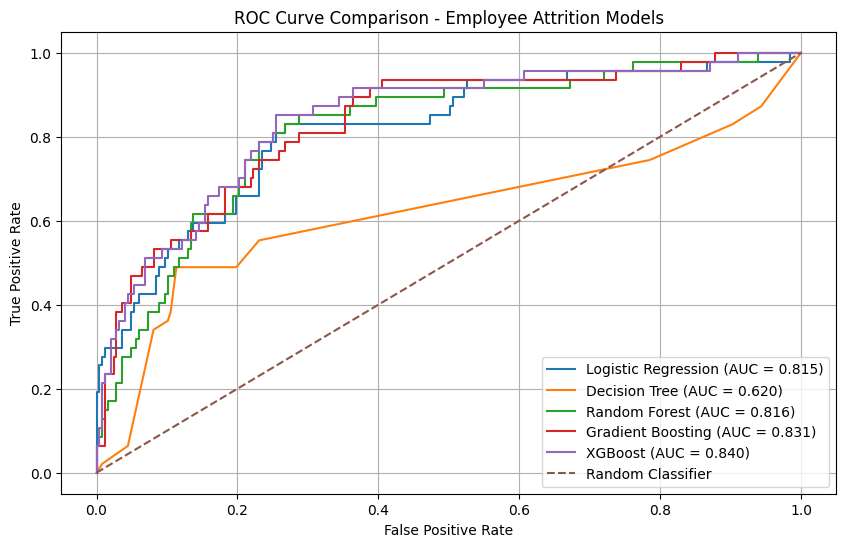

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, pipeline in model_pipelines.items():

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Employee Attrition Models")
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix - XGBoost
[[242   5]
 [ 36  11]]


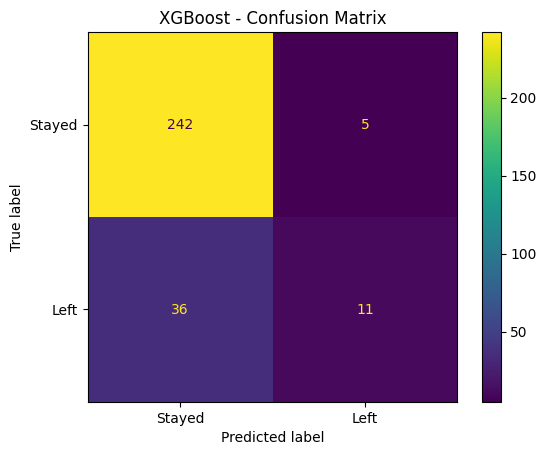

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model_name = "XGBoost"

best_model = model_pipelines[best_model_name]

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix - XGBoost")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [40]:
# Get the trained XGBoost pipeline
xgb_pipeline = model_pipelines["XGBoost"]

# Get the preprocessing step
preprocessor_fitted = xgb_pipeline.named_steps["preprocessor"]

# Get the trained XGBoost model
xgb_model = xgb_pipeline.named_steps["model"]

# Get feature names after preprocessing
feature_names = preprocessor_fitted.get_feature_names_out()

# Get feature importance
importance = xgb_model.feature_importances_

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort from highest to lowest
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("===== TOP 20 FEATURES =====")
display(feature_importance_df.head(20))

===== TOP 20 FEATURES =====


,Feature,Importance
4,num__total_working_years,0.104451
3,num__job_level,0.060142
8,num__years_with_curr_manager,0.054328
50,cat__overtime_No,0.046459
26,cat__marital_status_Divorced,0.041127
16,num__stock_option_level,0.040047
45,cat__job_role_Sales Executive,0.034841
1,num__age,0.033584
17,num__environment_satisfaction,0.028077
9,num__num_companies_worked,0.025115


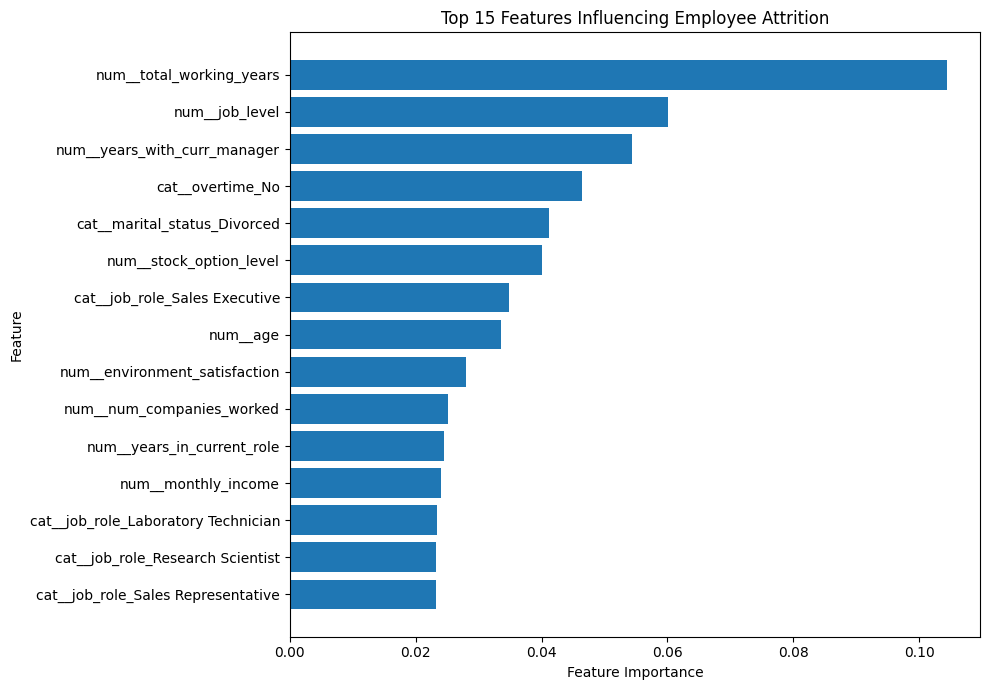

In [41]:
top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Employee Attrition")

plt.tight_layout()
plt.show()

In [42]:
import joblib

final_model = model_pipelines["XGBoost"]

joblib.dump(
    final_model,
    "xgboost_attrition_pipeline.pkl"
)

print("Final XGBoost model saved successfully.")

Final XGBoost model saved successfully.


In [43]:
import os

print("File exists:", os.path.exists("xgboost_attrition_pipeline.pkl"))

File exists: True


In [44]:
loaded_model = joblib.load(
    "xgboost_attrition_pipeline.pkl"
)

test_predictions = loaded_model.predict(X_test)

print("Model loaded successfully.")
print("Test predictions generated:", len(test_predictions))

Model loaded successfully.
Test predictions generated: 294


## ML Modeling Conclusion

Five classification models were trained and evaluated for employee
attrition prediction:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost

The models were compared using Accuracy, Precision, Recall, F1 Score,
and ROC-AUC.

Gradient Boosting achieved the highest accuracy (86.73%) and precision
(78.57%), while Logistic Regression achieved the highest recall (65.96%)
and F1 Score (45.93%) for the employee attrition class.

XGBoost achieved the highest ROC-AUC score of 0.8400 and was selected
as the primary model for the project.

The XGBoost pipeline was saved and successfully reloaded, confirming
that the trained preprocessing and prediction pipeline can be reused
for future employee attrition predictions.

The model's feature importance analysis was also performed to identify
the workforce factors contributing most strongly to the model's
predictions.

In [45]:
import joblib

final_model = model_pipelines["XGBoost"]

joblib.dump(
    final_model,
    "xgboost_attrition_pipeline.pkl"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


In [46]:
import os

print(os.path.exists("xgboost_attrition_pipeline.pkl"))

True
